## Setup

In [173]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))


In [174]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /Users/hamza/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/hamza/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [175]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt


In [176]:
import src.pdf_reader as pdf_reader
import src.text_processor as text_processor
import src.vocab_builder as vocab_builder
import src.example_extractor as example_extractor
import src.vocab_ranker as vocab_ranker
import src.definition_extractor as definition_extractor


importlib.reload(pdf_reader)
importlib.reload(text_processor)
importlib.reload(vocab_builder)
importlib.reload(example_extractor)
importlib.reload(vocab_ranker)
importlib.reload(definition_extractor)

from src.pdf_reader import extract_text_from_pdf
from src.text_processor import process_text
from src.vocab_builder import build_vocabulary
from src.example_extractor import add_example_sentences
from src.vocab_ranker import rank_vocabulary
from src.definition_extractor import add_definitions



## Config

In [177]:
BOOK_PATH = "../data/raw/book.pdf"
MIN_FREQUENCY = 2
TOP_N = 20


## Read the PDF

In [178]:
text = extract_text_from_pdf(BOOK_PATH)

print(text[:2000])



PRAISE FOR
A COUNTRY DOCTOR’S NOTEBOOK
“This book has a freshness and liveliness … an epic quality because of the background 
Russia’s vastness, the great distances, the weight of the ignorance, the need.”
—DORIS LESSI
“These straightforward yet extraordinary sketches gain their strength from also being th
account of a young man’s growth. One begins to see that he became a novelist not becau
he had material but because he was storing up passion and temperament.”
—V.S. PRITCHETT, NEW STATESM
“Stories as keen and bright as a scalpel … Courage shines from every angle of th
profoundly human collection by the greatest of modern Russian writers.”
—SUNDAY TIM
“Bulgakov casts a wonderfully wry, self-deprecating humour. His compassion for huma
folly is unfailing … These stories stand testament both to human resilience and 
remarkable literary talent.”
—THE INDEPENDE

A COUNTRY DOCTOR’S NOTEBOOK
MIKHAIL BULGAKOV (1891–1940) was born in Kiev, one of seven children born to a
university lecturer a

Quick check just to make sure the text extraction looks normal before doing anything else.

##  Process the text

In [179]:
tokens = process_text(text)

len(tokens)


47860

In [180]:
tokens[:20]


[{'word': 'praise',
  'lemma': 'praise',
  'pos': 'VERB',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'for',
  'lemma': 'for',
  'pos': 'ADP',
  'is_stop': True,
  'ent_type': '',
  'is_title': False},
 {'word': 'a',
  'lemma': 'a',
  'pos': 'DET',
  'is_stop': True,
  'ent_type': '',
  'is_title': True},
 {'word': 'country',
  'lemma': 'country',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'doctor',
  'lemma': 'doctor',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'notebook',
  'lemma': 'notebook',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'this',
  'lemma': 'this',
  'pos': 'DET',
  'is_stop': True,
  'ent_type': '',
  'is_title': True},
 {'word': 'book',
  'lemma': 'book',
  'pos': 'NOUN',
  'is_stop': False,
  'ent_type': '',
  'is_title': False},
 {'word': 'has',
  'lemma': 'have',
  'pos': 'VERB',
  'is_stop': True,
  'ent_typ

In [181]:
vocab_df = build_vocabulary(tokens, min_frequency=MIN_FREQUENCY)

vocab_df.head(30)


,lemma,pos,frequency
0,say,VERB,173
1,come,VERB,145
2,woman,NOUN,126
3,doctor,NOUN,120
4,eye,NOUN,112
5,time,NOUN,105
6,look,VERB,94
7,feel,VERB,91
8,think,VERB,91
9,man,NOUN,82


In [182]:
vocab_df.shape

(2372, 3)

In [183]:
vocab_df.sample(20)


,lemma,pos,frequency
1747,doleful,ADJ,2
998,novel,NOUN,4
781,mad,ADJ,5
637,pneumonia,NOUN,6
1805,fearful,ADJ,2
425,weak,ADJ,9
1491,undressed,ADJ,3
528,mere,ADJ,7
1826,french,ADJ,2
931,firm,ADJ,4


## Basic inspection

In [184]:
vocab_df["frequency"].describe()


count    2372.000000
mean        6.765599
std        11.208835
min         2.000000
25%         2.000000
50%         3.000000
75%         6.000000
max       173.000000
Name: frequency, dtype: float64

In [185]:
vocab_df["pos"].value_counts()


pos
NOUN    1140
VERB     663
ADJ      407
ADV      162
Name: count, dtype: int64

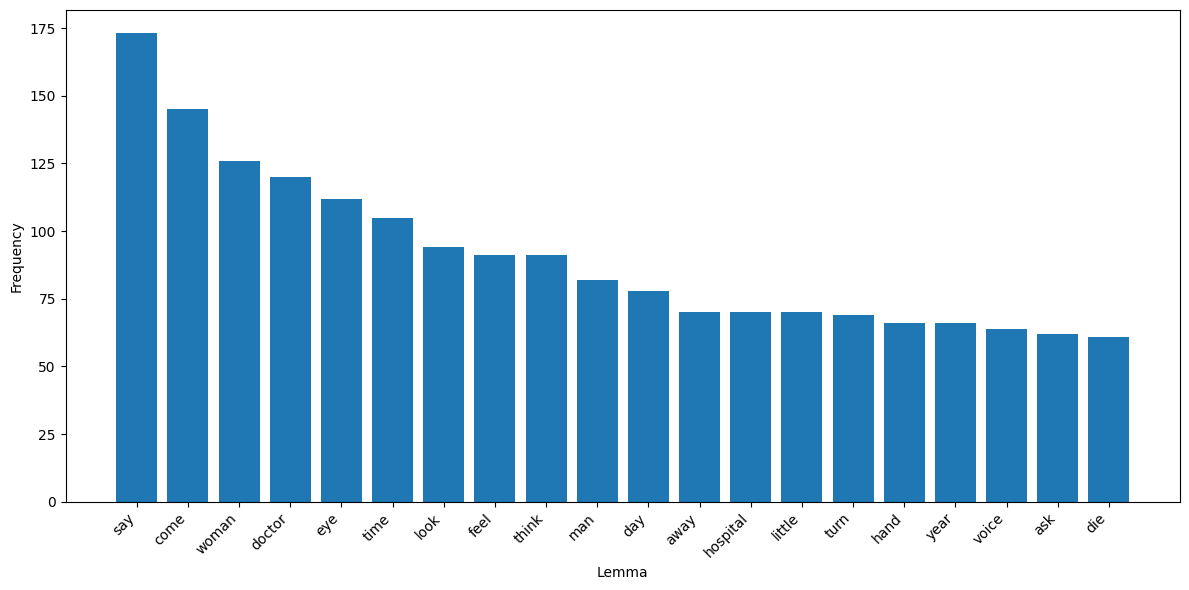

In [186]:
top_vocab = vocab_df.head(TOP_N)

plt.figure(figsize=(12, 6))
plt.bar(top_vocab["lemma"], top_vocab["frequency"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


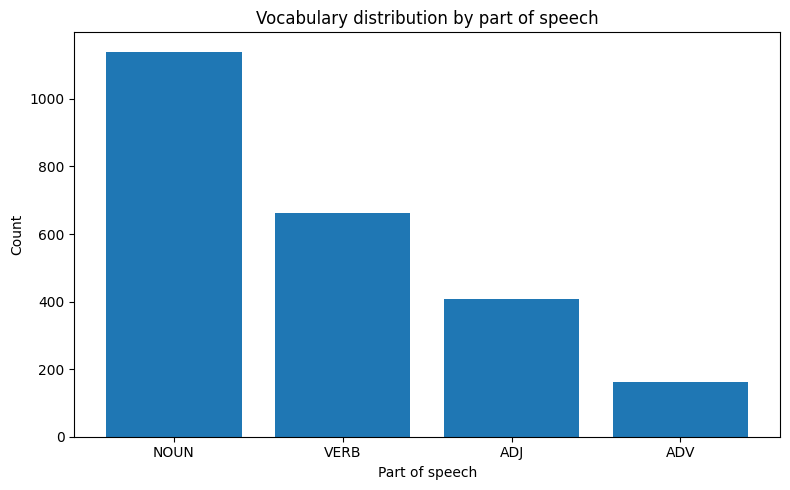

In [187]:
pos_counts = vocab_df["pos"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(pos_counts.index, pos_counts.values)
plt.xlabel("Part of speech")
plt.ylabel("Count")
plt.title("Vocabulary distribution by part of speech")
plt.tight_layout()
plt.show()


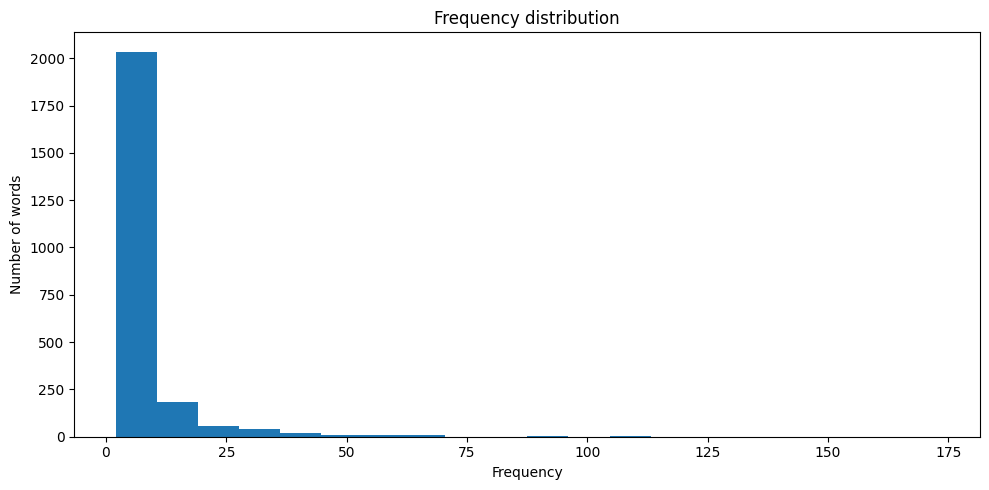

In [188]:
plt.figure(figsize=(10, 5))
plt.hist(vocab_df["frequency"], bins=20)
plt.xlabel("Frequency")
plt.ylabel("Number of words")
plt.title("Frequency distribution")
plt.tight_layout()
plt.show()


## Adding example sentences

In [189]:
vocab_with_examples = add_example_sentences(vocab_df, text)

vocab_with_examples[["lemma", "frequency", "example_sentence"]].head(20)


,lemma,frequency,example_sentence
0,say,173,Do you know what they ’re **saying** in the vi...
1,come,145,I turned round and saw that a round - faced ol...
2,woman,126,I turned round and saw that a round - faced ol...
3,doctor,120,A few minutes later I was standing beside the ...
4,eye,112,I raised her cold eyelid and looked with super...
5,time,105,All the **time** a ɹne rain was drizzling down...
6,look,94,And as you die a slow death there ’s nothing t...
7,feel,91,Thereupon I regained my wits and started **fee...
8,think,91,Just **think** … I actually had to put up for ...
9,man,82,and I saw a **man** hobbling towards me in a r...


In [190]:
vocab_with_examples.sample(10)


,lemma,pos,frequency,example_sentence
721,diagnosis,NOUN,5,In a burst of conɹdence I felt that this must ...
550,second,NOUN,7,But a few **seconds** later he had to cover her.
494,colour,NOUN,7,Her eyes began to shine and her cheekbones flu...
1208,dilute,VERB,3,What remained of the blood in the girl ’s vein...
808,register,VERB,5,Both were watching with intense concentration ...
1852,grey,NOUN,2,I muttered and pulled at his **grey** sleeve.
1263,growl,VERB,3,Lukich **growled** and made a grimace of pity ...
1885,hopelessly,ADV,2,For the fact was that my methods were purely h...
797,perfectly,ADV,5,"But there was no point in this, as I had **per..."
827,sob,NOUN,5,"‘ The swine, ’ the young woman **sobbed** and ..."


In [191]:
vocab_with_examples["example_sentence"].isna().sum()


np.int64(0)

This is the part I mostly care about when checking quality. If the examples look weird, I need to improve the filtering or sentence scoring.

## Rank the vocabulary

In [192]:
ranked_vocab_df = rank_vocabulary(vocab_with_examples)

ranked_vocab_df[["lemma", "pos", "frequency", "zipf_frequency", "vocab_score", "example_sentence"]].head(30)


,lemma,pos,frequency,zipf_frequency,vocab_score,example_sentence
0,sleigh,NOUN,29,2.99,17.039999,I could hear the creaking of **sleigh** - runn...
1,hoarse,ADJ,13,2.66,16.206451,‘ “ A deserter? ” croaked the now familiar **h...
2,morphine,NOUN,32,3.37,16.188830,The **morphine** worked sooner than I had expe...
3,midwife,NOUN,28,3.27,15.927309,A **midwife** took a firm hold of the old woma...
4,gauze,NOUN,20,2.89,15.557510,Lying on a piece of **gauze** on the table was...
5,sheepskin,NOUN,15,2.50,15.249238,Where are you from? ’ The **sheepskin** coat f...
6,doctor,NOUN,120,4.90,14.866951,A few minutes later I was standing beside the ...
7,gramme,NOUN,9,1.64,14.644441,There were only two syringes — a small one- **...
8,lamp,NOUN,38,4.05,14.471069,The pressure - **lamp** with its lopsided tin ...
9,syrinx,NOUN,9,1.83,14.206950,There were only two **syringes** — a small one...


In [193]:
ranked_vocab_df[["lemma", "frequency", "zipf_frequency", "vocab_score"]].sample(20)


,lemma,frequency,zipf_frequency,vocab_score
1196,solemn,2,3.41,5.799025
1072,idea,9,5.36,6.078825
1012,addiction,4,4.14,6.212430
872,ampoule,2,2.04,6.547729
784,touch,8,4.91,6.789424
857,station,8,5.01,6.569701
553,version,12,5.07,7.515302
105,faint,8,3.78,10.663131
36,speckled,7,2.81,12.411147
983,belly,4,4.10,6.276808


In [194]:
ranked_vocab_df["zipf_frequency"].describe()


count    2372.000000
mean        4.096657
std         1.197907
min         0.000000
25%         3.597500
50%         4.330000
75%         4.900000
max         6.710000
Name: zipf_frequency, dtype: float64

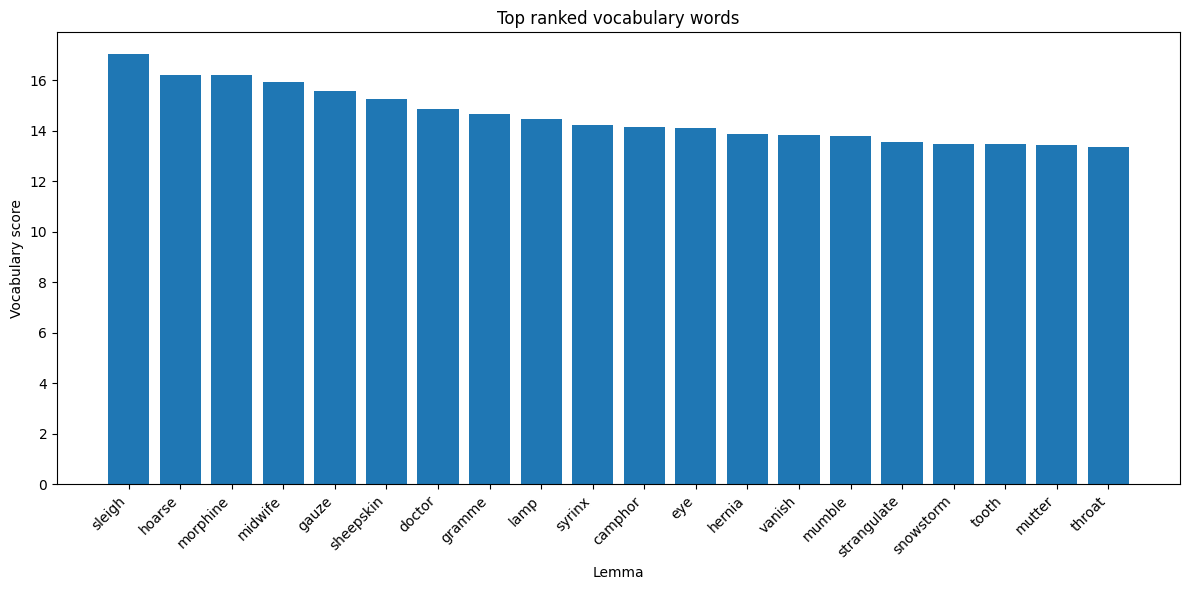

In [195]:
top_ranked = ranked_vocab_df.head(TOP_N)

plt.figure(figsize=(12, 6))
plt.bar(top_ranked["lemma"], top_ranked["vocab_score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Lemma")
plt.ylabel("Vocabulary score")
plt.title("Top ranked vocabulary words")
plt.tight_layout()
plt.show()


In [ ]:
vocab_with_definitions = add_definitions(ranked_vocab_df)
vocab_with_definitions[
    ["lemma", "pos", "frequency", "definition", "example_sentence"]
].head(20)

,lemma,pos,frequency,definition,example_sentence
0,sleigh,NOUN,29,a vehicle mounted on runners and pulled by hor...,I could hear the creaking of **sleigh** - runn...
1,hoarse,ADJ,13,deep and harsh sounding as if from shouting or...,‘ “ A deserter? ” croaked the now familiar **h...
2,morphine,NOUN,32,an alkaloid narcotic drug extracted from opium...,The **morphine** worked sooner than I had expe...
3,midwife,NOUN,28,a woman skilled in aiding the delivery of babies,A **midwife** took a firm hold of the old woma...
4,gauze,NOUN,20,(medicine) bleached cotton cloth of plain weav...,Lying on a piece of **gauze** on the table was...
5,sheepskin,NOUN,15,tanned skin of a sheep with the fleece left on...,Where are you from? ’ The **sheepskin** coat f...
6,doctor,NOUN,120,a licensed medical practitioner,A few minutes later I was standing beside the ...
7,gramme,NOUN,9,a metric unit of weight equal to one thousandt...,There were only two syringes — a small one- **...
8,lamp,NOUN,38,an artificial source of visible illumination,The pressure - **lamp** with its lopsided tin ...
9,syrinx,NOUN,9,a primitive wind instrument consisting of seve...,There were only two **syringes** — a small one...


##  Export

In [199]:
vocab_with_examples.to_csv("../outputs/vocabulary_with_examples.csv", index=False)
ranked_vocab_df.to_csv("../outputs/ranked_vocabulary.csv", index=False)
vocab_with_definitions.to_csv("../outputs/vocabulary_with_definitions.csv", index=False)


In [200]:
study_df = vocab_with_definitions[
    ["lemma", "pos", "frequency", "zipf_frequency", "vocab_score","definition" ,"example_sentence"]
].copy()

study_df.head(20)


,lemma,pos,frequency,zipf_frequency,vocab_score,definition,example_sentence
0,sleigh,NOUN,29,2.99,17.039999,a vehicle mounted on runners and pulled by hor...,I could hear the creaking of **sleigh** - runn...
1,hoarse,ADJ,13,2.66,16.206451,deep and harsh sounding as if from shouting or...,‘ “ A deserter? ” croaked the now familiar **h...
2,morphine,NOUN,32,3.37,16.188830,an alkaloid narcotic drug extracted from opium...,The **morphine** worked sooner than I had expe...
3,midwife,NOUN,28,3.27,15.927309,a woman skilled in aiding the delivery of babies,A **midwife** took a firm hold of the old woma...
4,gauze,NOUN,20,2.89,15.557510,(medicine) bleached cotton cloth of plain weav...,Lying on a piece of **gauze** on the table was...
5,sheepskin,NOUN,15,2.50,15.249238,tanned skin of a sheep with the fleece left on...,Where are you from? ’ The **sheepskin** coat f...
6,doctor,NOUN,120,4.90,14.866951,a licensed medical practitioner,A few minutes later I was standing beside the ...
7,gramme,NOUN,9,1.64,14.644441,a metric unit of weight equal to one thousandt...,There were only two syringes — a small one- **...
8,lamp,NOUN,38,4.05,14.471069,an artificial source of visible illumination,The pressure - **lamp** with its lopsided tin ...
9,syrinx,NOUN,9,1.83,14.206950,a primitive wind instrument consisting of seve...,There were only two **syringes** — a small one...


In [204]:
len(study_df)

2372

In [202]:
vocab_with_definitions[vocab_with_definitions["definition"].isna()].count()

lemma                   120
pos                     120
frequency               120
example_sentence        120
zipf_frequency          120
book_frequency_score    120
rarity_score            120
pos_weight              120
vocab_score             120
definition                0
dtype: int64

In [201]:
vocab_with_definitions[vocab_with_definitions["definition"].isna()].head(20)

,lemma,pos,frequency,example_sentence,zipf_frequency,book_frequency_score,rarity_score,pos_weight,vocab_score,definition
39,feldsher,NOUN,59,‘ Yes … ’ the **feldsher** pronounced softly a...,0.00,4.094345,3.00,1.00,12.283034,NaN
48,ɹrst,ADJ,31,‘ I ’ve got my degree and a **ɹrst** class one...,0.00,3.465736,3.00,1.15,11.956789,NaN
147,ɹnd,VERB,28,Just tell me how I ’ll **ɹnd** my bearings wit...,0.00,3.367296,3.00,1.00,10.101887,NaN
189,ɻoor,NOUN,24,The **ɻoor** was covered in white blobs of gyp...,0.00,3.218876,3.00,1.00,9.656627,NaN
194,ipecacuanha,NOUN,3,I ’ll also prescribe an infusion of **ipecacua...,1.05,1.386294,6.95,1.00,9.634746,NaN
215,soundless,NOUN,4,"In short, in a normal dream music is **soundle...",2.11,1.609438,5.89,1.00,9.479589,NaN
389,snowbound,NOUN,3,"In other words, it was pitiful, **snowbound** ...",2.03,1.386294,5.97,1.00,8.276177,NaN
431,operating,NOUN,11,The **operating** theatre had begun to take on...,4.75,2.484907,3.25,1.00,8.075947,NaN
443,gramme,ADJ,2,There were only two syringes — a small one- **...,1.64,1.098612,6.36,1.15,8.035250,NaN
512,ɹnger,NOUN,12,I washed oʃ the thick lather and painted my **...,0.00,2.564949,3.00,1.00,7.694848,NaN
